## R-Star testing with the inclusion of oscillation parameters

The `xsec_` parameters are known as the 'nuisance paramters' since they are there because they have to be there; what is more interesting are the oscillation params which tell us about the PMNS matrix and ulitmately CP violation. We are essentially limit testing R* on data that looks wierd. 

The distribution of delta_m232 is 2 gaussians, one on the rhs of the y axis (referred to as the normal ordering) and one on the left (referred to as reverse ordering); we want to know how R* handles this and compare it R-Hat since the R-Hat diagnostic is based on between chain and within chain variances. This will be an effective comparison between the two diagnostics.

This notebook runs similar code to `basic_sklearn.ipynb` but with the inclusion of oscillation parameters. 

In [1]:
# MaCh3Python Deps
from MaCh3PythonUtils.file_handling.chain_handler import ChainHandler
from MaCh3PythonUtils.machine_learning.ml_factory import MLFactory
from MaCh3PythonUtils.file_handling.chain_diagnostics import ChainDiagnostics
from sklearn.model_selection import LearningCurveDisplay
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import log_loss    


# Other imports
from matplotlib import pyplot as plt
from pathlib import Path
import numpy as np
import random as rand
import os
import pandas as pd
import seaborn as sns
import gdown
import arviz as az
import xarray as xr

Using mps device

## How does R* behave when 2 identical chain files slowly become more random with the inclusion of oscillation paramters.
> At what value of R* can we say with confidence that the ML Classifier distinguishes between the 2 chains as good as random guessing.

The code below is similar to the code in `basic_sklearn.ipynb` with the addition of the oscillation params.


In [2]:
#this code is for all_fixed_AdT2K: the 2 files are identical
# NEXT STEP: add more folders that have increasing levels of randomness, use notebook to infer 
path_to_identical= Path("../models/demo_files 2/all_on_ADT2K/identical/")
path_to_1= Path("../models/demo_files 2/all_on_ADT2K/level 1/")
path_to_2= Path("../models/demo_files 2/all_on_ADT2K/level 2/")
path_to_3= Path("../models/demo_files 2/all_on_ADT2K/level 3/")
path_to_4= Path("../models/demo_files 2/all_on_ADT2K/level 4/")
path_to_5= Path("../models/demo_files 2/all_on_ADT2K/level 5/")
path_to_6= Path("../models/demo_files 2/all_on_ADT2K/level 6/")
path_to_7= Path("../models/demo_files 2/all_on_ADT2K/level 7/")

identical=[f"{path_to_identical}/{x}" for x in os.listdir(path_to_identical)] 
level1=[f'{path_to_1}/{y}' for y in os.listdir(path_to_1)]
level2=[f'{path_to_2}/{z}' for z in os.listdir(path_to_2)]
level3=[f'{path_to_3}/{a}' for a in os.listdir(path_to_3)]
level4=[f'{path_to_4}/{b}' for b in os.listdir(path_to_4)]
level5=[f'{path_to_5}/{c}' for c in os.listdir(path_to_5)]
level6=[f'{path_to_6}/{b}' for b in os.listdir(path_to_6)]
level7=[f'{path_to_7}/{c}' for c in os.listdir(path_to_7)]

fitting_label = "ID"
paths = [identical, level1, level2, level3, level4,level5, level6, level7]
for i in paths:
    print(i)
# chain_list [for file in folder ChainHandler(input_file, chain_name, verbose=verbse)]: Handler List : Hlist

temp_identical=[]
temp1=[]
temp2=[]
temp3=[]
temp4=[]
temp5=[]
temp6=[]
temp7=[]



for lm in paths:
    for x in lm:
        chain_handler = ChainHandler(x, 'posteriors', verbose='verbose')
            
        # Process all the files
        chain_handler.ignore_plots(['baseline', 'density', 'Ye', "xsec_19", "xsec_20",'sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp'])
        chain_handler.add_additional_plots(["xsec_0", "xsec_1", "xsec_2", "xsec_3", "xsec_4", "xsec_5", "xsec_6", "xsec_7", "xsec_8", "xsec_9", "xsec_10", "xsec_11", "xsec_12", "xsec_13",
                                            "xsec_14", "xsec_15", "xsec_16", "xsec_17", "xsec_18",  "xsec_21", "xsec_22"])
        #chain_handler.add_additional_plots(['sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp'])
        #We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
        # chain_handler.add_additional_plots(fitting_label, True)

        # Finally we can do some cuts to get rid of things like burn-in
        chain_handler.add_new_cuts(["LogL<22.5", "step>10000", "delm2_23>0"]) #>0 chooses the normal ordering; <0 chooses reverse ordering; removing the cut chooses both
        chain_handler.add_new_cuts(["step>0", "LogL_systematic_xsec_cov<12345"])

        # Last step is  convert the chain data files into a pandas dataframe
        y= chain_handler.convert_ttree_to_array()
        #chain_list_2.append(chain_handler)


        if lm == identical:
            temp_identical.append(chain_handler)
        elif lm == level1:
            temp1.append(chain_handler)
        elif lm == level2:
            temp2.append(chain_handler)
        elif lm == level3:
            temp3.append(chain_handler)
        elif lm == level4:
            temp4.append(chain_handler)
        elif lm == level5:
            temp5.append(chain_handler)
        elif lm == level6:
            temp6.append(chain_handler)
        elif lm == level7:
            temp7.append(chain_handler)


identical_data = temp_identical[0]
identical_data2= temp_identical[1]

level1_data = temp1[0]
level1_data2= temp1[1]


for m in range(23):
    if m == 19:
        continue
    elif m == 20:
        continue
    level1_data2.ttree_array[f'xsec_{m}']= level1_data2.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(level1_data2.ttree_array[f'xsec_{m}']))*1e-5)
"""
level1_data2.ttree_array[f'sin2th_12']= level1_data2.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(level1_data2.ttree_array[f'sin2th_12']))*1e-5)
level1_data2.ttree_array[f'sin2th_23']=level1_data2.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(level1_data2.ttree_array[f'sin2th_23']))*1e-5)
level1_data2.ttree_array[f'sin2th_13']=level1_data2.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(level1_data2.ttree_array[f'sin2th_13']))*1e-5)
level1_data2.ttree_array[f'delm2_12']=level1_data2.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(level1_data2.ttree_array[f'delm2_12']))*1e-5)
level1_data2.ttree_array[f'delm2_23']=level1_data2.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(level1_data2.ttree_array[f'delm2_23']))*1e-5)

level1_data2.ttree_array[f'delta_cp']=level1_data2.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(level1_data2.ttree_array[f'delta_cp']))*1e-5)"""


level2_data = temp2[0]
level2_data2= temp2[1]


for m in range(23):
    if m == 19:
        continue
    elif m == 20:
        continue
    level2_data2.ttree_array[f'xsec_{m}']= level2_data2.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(level2_data2.ttree_array[f'xsec_{m}']))*1e-4)

"""level2_data2.ttree_array[f'sin2th_12']= level2_data2.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(level2_data2.ttree_array[f'sin2th_12']))*1e-4)
level2_data2.ttree_array[f'sin2th_23']=level2_data2.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(level2_data2.ttree_array[f'sin2th_23']))*1e-4)
level2_data2.ttree_array[f'sin2th_13']=level2_data2.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(level2_data2.ttree_array[f'sin2th_13']))*1e-4)
level2_data2.ttree_array[f'delm2_12']=level2_data2.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(level2_data2.ttree_array[f'delm2_12']))*1e-4)
level2_data2.ttree_array[f'delm2_23']=level2_data2.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(level2_data2.ttree_array[f'delm2_23']))*1e-4)

level2_data2.ttree_array[f'delta_cp']=level2_data2.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(level2_data2.ttree_array[f'delta_cp']))*1e-4)"""


level3_data = temp3[0]
level3_data2= temp3[1]


for m in range(23):
    if m == 19:
        continue
    elif m == 20:
        continue
    level3_data2.ttree_array[f'xsec_{m}']= level3_data2.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(level3_data2.ttree_array[f'xsec_{m}']))*1e-3)

"""level3_data2.ttree_array[f'sin2th_12']= level3_data2.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(level3_data2.ttree_array[f'sin2th_12']))*1e-3)
level3_data2.ttree_array[f'sin2th_23']=level3_data2.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(level3_data2.ttree_array[f'sin2th_23']))*1e-3)
level3_data2.ttree_array[f'sin2th_13']=level3_data2.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(level3_data2.ttree_array[f'sin2th_13']))*1e-3)
level3_data2.ttree_array[f'delm2_12']=level3_data2.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(level3_data2.ttree_array[f'delm2_12']))*1e-3)
level3_data2.ttree_array[f'delm2_23']=level3_data2.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(level3_data2.ttree_array[f'delm2_23']))*1e-3)

level3_data2.ttree_array[f'delta_cp']=level3_data2.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(level3_data2.ttree_array[f'delta_cp']))*1e-3)"""


level4_data = temp4[0]
level4_data2= temp4[1]



for m in range(23):
    if m == 19:
        continue
    elif m == 20:
        continue
    level4_data2.ttree_array[f'xsec_{m}']= level4_data2.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(level4_data2.ttree_array[f'xsec_{m}']))*1e-2)

"""level4_data2.ttree_array[f'sin2th_12']= level4_data2.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(level4_data2.ttree_array[f'sin2th_12']))*1e-2)
level4_data2.ttree_array[f'sin2th_23']=level4_data2.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(level4_data2.ttree_array[f'sin2th_23']))*1e-2)
level4_data2.ttree_array[f'sin2th_13']=level4_data2.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(level4_data2.ttree_array[f'sin2th_13']))*1e-2)
level4_data2.ttree_array[f'delm2_12']=level4_data2.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(level4_data2.ttree_array[f'delm2_12']))*1e-2)
level4_data2.ttree_array[f'delm2_23']=level4_data2.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(level4_data2.ttree_array[f'delm2_23']))*1e-2)

level4_data2.ttree_array[f'delta_cp']=level4_data2.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(level4_data2.ttree_array[f'delta_cp']))*1e-2)"""



level5_data = temp5[0]
level5_data2= temp5[1]



for m in range(23):
    if m == 19:
        continue
    elif m == 20:
        continue
    level5_data2.ttree_array[f'xsec_{m}']= level5_data2.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(level5_data2.ttree_array[f'xsec_{m}']))*1e-1)
"""
level5_data2.ttree_array[f'sin2th_12']= level5_data2.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(level5_data2.ttree_array[f'sin2th_12']))*1e-1)
level5_data2.ttree_array[f'sin2th_23']=level5_data2.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(level5_data2.ttree_array[f'sin2th_23']))*1e-1)
level5_data2.ttree_array[f'sin2th_13']=level5_data2.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(level5_data2.ttree_array[f'sin2th_13']))*1e-1)
level5_data2.ttree_array[f'delm2_12']=level5_data2.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(level5_data2.ttree_array[f'delm2_12']))*1e-1)
level5_data2.ttree_array[f'delm2_23']=level5_data2.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(level5_data2.ttree_array[f'delm2_23']))*1e-1)

level5_data2.ttree_array[f'delta_cp']=level5_data2.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(level5_data2.ttree_array[f'delta_cp']))*1e-1)"""



level6_data = temp6[0]
level6_data2= temp6[1]

for m in range(23):
    if m == 19:
        continue  
    elif m == 20:
        continue
    level6_data2.ttree_array[f'xsec_{m}']= level6_data2.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(level6_data2.ttree_array[f'xsec_{m}'])))
"""
level6_data2.ttree_array[f'sin2th_12']= level6_data2.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(level6_data2.ttree_array[f'sin2th_12'])))
level6_data2.ttree_array[f'sin2th_23']=level6_data2.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(level6_data2.ttree_array[f'sin2th_23'])))
level6_data2.ttree_array[f'sin2th_13']=level6_data2.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(level6_data2.ttree_array[f'sin2th_13'])))
level6_data2.ttree_array[f'delm2_12']=level6_data2.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(level6_data2.ttree_array[f'delm2_12'])))
level6_data2.ttree_array[f'delm2_23']=level6_data2.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(level6_data2.ttree_array[f'delm2_23'])))

level6_data2.ttree_array[f'delta_cp']=level6_data2.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(level6_data2.ttree_array[f'delta_cp'])))"""


level7_data = temp7[0]
level7_data2= temp7[1]



for m in range(23):
    if m == 19:
        continue
    elif m == 20:
        continue
    level7_data2.ttree_array[f'xsec_{m}']= level7_data2.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(level7_data2.ttree_array[f'xsec_{m}']))*10)

"""level7_data2.ttree_array[f'sin2th_12']= level7_data2.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(level7_data2.ttree_array[f'sin2th_12']))*10)
level7_data2.ttree_array[f'sin2th_23']=level7_data2.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(level7_data2.ttree_array[f'sin2th_23']))*10)
level7_data2.ttree_array[f'sin2th_13']=level7_data2.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(level7_data2.ttree_array[f'sin2th_13']))*10)
level7_data2.ttree_array[f'delm2_12']=level7_data2.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(level7_data2.ttree_array[f'delm2_12']))*10)
level7_data2.ttree_array[f'delm2_23']=level7_data2.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(level7_data2.ttree_array[f'delm2_23']))*10)

level7_data2.ttree_array[f'delta_cp']=level7_data2.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(level7_data2.ttree_array[f'delta_cp']))*10)"""
# Convert the pandas DataFrame for each chain to a numpy array.
# This is necessary because ArviZ expects numpy arrays or xarray objects, not DataFrames.

res=[] #converts the DatFrames into numpy arrays, appends them to a list (res)
a= [identical_data, identical_data2, level1_data, level1_data2, level2_data, level2_data2, level3_data, level3_data2, level4_data, level4_data2, level5_data, level5_data2, level6_data, level6_data2, level7_data, level7_data2]
for n in a:
    new= n.ttree_array.values
    res.append(new)

#array1 = identical_data.ttree_array.values  # shape is shape (n_draws, n_params)
#array2 = identical_data2.ttree_array.values  


#chains = np.stack([array1, array2]) # shape: (n_chains, n_draws, n_params); now need to extract a specific parameter and map to which chain it came from (n_chain) 
                                # and how many draws it has - the length of the coloumn (n_draws), since ArviZ allows you to pass (n_chain, n_draws) per parameter
chains_id= np.stack([res[0], res[1]])
chains_1= np.stack([res[2], res[3]])
chains_2= np.stack([res[4], res[5]])
chains_3= np.stack([res[6], res[7]])
chains_4= np.stack([res[8], res[9]])
chains_5= np.stack([res[10], res[11]])
chains_6= np.stack([res[12], res[13]])
chains_7= np.stack([res[14], res[15]])


param_names = identical_data2.ttree_array.columns.tolist()

# Build a dictionary (using dictionary comperehension: posterior= ... ) # where each parameter name maps to a (n_chains, n_draws) array.
                                                                                           
data_id = az.from_dict(posterior={name: chains_id[:,:,i] for i, name in enumerate(param_names)})# chains[:,:,i] selects all chains and draws for the i-th parameter.
                                                                                          # chains[:,:,i]== chains(n_chains, n_draws, n_params)
                                                                                           
data_1 = az.from_dict(posterior={name: chains_1[:,:,i] for i, name in enumerate(param_names)})
data_2 = az.from_dict(posterior={name: chains_2[:,:,i] for i, name in enumerate(param_names)})
data_3 = az.from_dict(posterior={name: chains_3[:,:,i] for i, name in enumerate(param_names)})
data_4 = az.from_dict(posterior={name: chains_4[:,:,i] for i, name in enumerate(param_names)})
data_5= az.from_dict(posterior={name: chains_5[:,:,i] for i, name in enumerate(param_names)})
data_6 = az.from_dict(posterior={name: chains_6[:,:,i] for i, name in enumerate(param_names)})
data_7 = az.from_dict(posterior={name: chains_7[:,:,i] for i, name in enumerate(param_names)})


rhat_id= az.rhat(data_id)
rhat1=az.rhat(data_1)
rhat2=az.rhat(data_2)
rhat3=az.rhat(data_3)
rhat4=az.rhat(data_4)
rhat5=az.rhat(data_5)
rhat6=az.rhat(data_6)
rhat7= az.rhat(data_7)

['../models/demo_files 2/all_on_ADT2K/identical/mcmc_Adapt_T2K_all_on_copy.root', '../models/demo_files 2/all_on_ADT2K/identical/mcmc_Adapt_T2K_all_on.root']
['../models/demo_files 2/all_on_ADT2K/level 1/mcmc_Adapt_T2K_all_on_copy.root', '../models/demo_files 2/all_on_ADT2K/level 1/mcmc_Adapt_T2K_all_on.root']
['../models/demo_files 2/all_on_ADT2K/level 2/mcmc_Adapt_T2K_all_on_copy.root', '../models/demo_files 2/all_on_ADT2K/level 2/mcmc_Adapt_T2K_all_on.root']
['../models/demo_files 2/all_on_ADT2K/level 3/mcmc_Adapt_T2K_all_on_copy.root', '../models/demo_files 2/all_on_ADT2K/level 3/mcmc_Adapt_T2K_all_on.root']
['../models/demo_files 2/all_on_ADT2K/level 4/mcmc_Adapt_T2K_all_on_copy.root', '../models/demo_files 2/all_on_ADT2K/level 4/mcmc_Adapt_T2K_all_on.root']
['../models/demo_files 2/all_on_ADT2K/level 5/mcmc_Adapt_T2K_all_on_copy.root', '../models/demo_files 2/all_on_ADT2K/level 5/mcmc_Adapt_T2K_all_on.root']
['../models/demo_files 2/all_on_ADT2K/level 6/mcmc_Adapt_T2K_all_on_copy

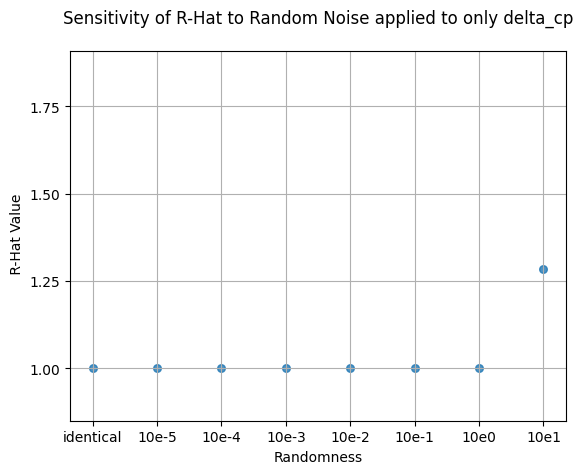

In [3]:

x = [2, 3, 4, 5, 6, 7, 8, 9]
y= [rhat_id['delta_cp'], rhat1['delta_cp'], rhat2['delta_cp'], rhat3['delta_cp'], rhat4['delta_cp'], rhat5['delta_cp'], rhat6['delta_cp'], rhat7['delta_cp'] ] 
ymin, ymax = min(y), max(y)
pad =0.5 #(ymax - ymin) * 0.3
plt.ylim(ymin-0.15, ymax + 0.625)
plt.xticks([2, 3, 4, 5, 6, 7, 8, 9], ['identical','10e-5', '10e-4', '10e-3', '10e-2', '10e-1', '10e0', '10e1'])
plt.yticks([1.00, 1.25, 1.50, 1.75], ['1.00','1.25', '1.50', '1.75'])

plt.scatter(x, y, alpha=0.8, s=30)


plt.rcParams["font.family"] = "Times"

#plt.gca().yaxis.set_major_locator(plt.MaxNLocator(5))   

plt.title('Sensitivity of R-Hat to Random Noise applied to only delta_cp', pad=20)
plt.xlabel('Randomness')
plt.ylabel(' R-Hat Value')
plt.savefig('filename.png', dpi=900)
plt.grid(True)
plt.show()



## Delayed-rejection adaptive MCMC chain versus Normal adaptive MCMC Chain 
<ins>Running RHAT</ins>

In [2]:
#this code is for all_fixed_AdT2K: the 2 files are identical
# NEXT STEP: add more folders that have increasing levels of randomness, use notebook to infer 
path_to_folder= Path("../models/demo_files 2/demo chain 3/")


files=[f"{path_to_folder}/{x}" for x in os.listdir(path_to_folder)] 




fitting_label = "ID"
paths = [files]
for i in paths:
    print(i)
# chain_list [for file in folder ChainHandler(input_file, chain_name, verbose=verbse)]: Handler List : Hlist

temp_identical=[]



for lm in paths:
    for x in lm:
        chain_handler = ChainHandler(x, 'posteriors', verbose='verbose')
            
        # Process all the files
        #chain_handler.ignore_plots(["xsec_20", "xsec_19", 'sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp', 'baseline', 'density', 'Ye'])
        chain_handler.add_additional_plots(["xsec_0", "xsec_1", "xsec_2", "xsec_3", "xsec_4", "xsec_5", "xsec_6", "xsec_7", "xsec_8", "xsec_9", "xsec_10", "xsec_11", "xsec_12", "xsec_13",
                                            "xsec_14", "xsec_15", "xsec_16", "xsec_17", "xsec_18", "xsec_21", "xsec_22", 'sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp'])
        #We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
        # chain_handler.add_additional_plots(fitting_label, True)

        # Finally we can do some cuts to get rid of things like burn-in
        chain_handler.add_new_cuts(["LogL<123456", "step>10000"])
        chain_handler.add_new_cuts(["step>0", "LogL_systematic_xsec_cov<123456"])

        # Last step is  convert the chain data files into a pandas dataframe
        y= chain_handler.convert_ttree_to_array()
        #chain_list_2.append(chain_handler)


        if lm == files:
            temp_identical.append(chain_handler)
 

identical_data = temp_identical[0]
identical_data2= temp_identical[1]





res=[] #converts the DatFrames into numpy arrays, appends them to a list (res)
a= [identical_data, identical_data2]
for n in a:
    new= n.ttree_array.values
    res.append(new)
print(len(res[0]))
print(len(res[1]))

lengths = [n.shape[0] for n in res]
min_len = min(lengths)

res_trimmed = [arr[:min_len, :] for arr in res]
chains_id = np.stack(res_trimmed)

param_names = identical_data2.ttree_array.columns.tolist()
                                                                                           
data_id = az.from_dict(posterior={name: chains_id[:,:,i] for i, name in enumerate(param_names)})
rhat_id= az.rhat(data_id)

print(rhat_id)


['../models/demo_files 2/demo chain 3/Test_delayed_no_sample_no_flat_adaptive.root', '../models/demo_files 2/demo chain 3/Test_mcmc_no_sample_no_flat_adaptive.root']
Attempting to open ../models/demo_files 2/demo chain 3/Test_delayed_no_sample_no_flat_adaptive.root
Succesfully opened ../models/demo_files 2/demo chain 3/Test_delayed_no_sample_no_flat_adaptive.root:posteriors
Using 12 threads and requiring 0.164 Gb memory
Using the following branches: 
  -> xsec_0
  -> xsec_1
  -> xsec_2
  -> xsec_3
  -> xsec_4
  -> xsec_5
  -> sin2th_12
  -> sin2th_23
  -> sin2th_13
  -> delm2_12
  -> delm2_23
  -> delta_cp
Converted TTree to pandas dataframe with 988272 elements
Attempting to open ../models/demo_files 2/demo chain 3/Test_mcmc_no_sample_no_flat_adaptive.root
Succesfully opened ../models/demo_files 2/demo chain 3/Test_mcmc_no_sample_no_flat_adaptive.root:posteriors
Using 12 threads and requiring 0.164 Gb memory
Using the following branches: 
  -> xsec_0
  -> xsec_1
  -> xsec_2
  -> xsec_

### <ins>Delayed </ins> Correlated Bounded Adaptive versus <ins> Normal </ins> Correlated Bounded Adaptive
- Running RHAT

In [ ]:
#this code is for all_fixed_AdT2K: the 2 files are identical
# NEXT STEP: add more folders that have increasing levels of randomness, use notebook to infer 
path_to_folder= Path("../models/demo_files 2/adaptive_correlated/")


files=[f"{path_to_folder}/{x}" for x in os.listdir(path_to_folder)] 




fitting_label = "ID"
paths = [files]
for i in paths:
    print(i)
# chain_list [for file in folder ChainHandler(input_file, chain_name, verbose=verbse)]: Handler List : Hlist

temp_identical=[]



for lm in paths:
    for x in lm:
        chain_handler = ChainHandler(x, 'posteriors', verbose='verbose')
            
        # Process all the files
        #chain_handler.ignore_plots(["xsec_20", "xsec_19", 'sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp', 'baseline', 'density', 'Ye'])
        chain_handler.add_additional_plots(["xsec_0", "xsec_1", "xsec_2", "xsec_3", "xsec_4", "xsec_5", "xsec_6", "xsec_7", "xsec_8", "xsec_9", "xsec_10", "xsec_11", "xsec_12", "xsec_13",
                                            "xsec_14", "xsec_15", "xsec_16", "xsec_17", "xsec_18", "xsec_21", "xsec_22", 'sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp'])
        #We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
        # chain_handler.add_additional_plots(fitting_label, True)

        # Finally we can do some cuts to get rid of things like burn-in
        chain_handler.add_new_cuts(["LogL<123456", "step>10000"])
        chain_handler.add_new_cuts(["step>0", "LogL_systematic_xsec_cov<123456"])

        # Last step is  convert the chain data files into a pandas dataframe
        y= chain_handler.convert_ttree_to_array()
        #chain_list_2.append(chain_handler)


        if lm == files:
            temp_identical.append(chain_handler)
 

identical_data = temp_identical[0]
identical_data2= temp_identical[1]





res=[] #converts the DatFrames into numpy arrays, appends them to a list (res)
a= [identical_data, identical_data2]
for n in a:
    new= n.ttree_array.values
    res.append(new)
#print(len(res[0]))
#print(len(res[1]))

lengths = [n.shape[0] for n in res]
min_len = min(lengths)

res_trimmed = [arr[:min_len, :] for arr in res]
chains_id = np.stack(res_trimmed)

param_names = identical_data2.ttree_array.columns.tolist()
                                                                                           
data_id = az.from_dict(posterior={name: chains_id[:,:,i] for i, name in enumerate(param_names)})
rhat_id= az.rhat(data_id)

print(rhat_id)


['../models/demo_files 2/adaptive_correlated/delayed_correlated_bounded_no_osc_flips.root', '../models/demo_files 2/adaptive_correlated/mcmc_correlated_bounded_no_osc_flips.root']
Attempting to open ../models/demo_files 2/adaptive_correlated/delayed_correlated_bounded_no_osc_flips.root
Succesfully opened ../models/demo_files 2/adaptive_correlated/delayed_correlated_bounded_no_osc_flips.root:posteriors
Using 12 threads and requiring 0.392 Gb memory
Using the following branches: 
  -> xsec_0
  -> xsec_1
  -> xsec_2
  -> xsec_3
  -> xsec_4
  -> xsec_5
  -> xsec_6
  -> xsec_7
  -> xsec_8
  -> xsec_9
  -> sin2th_12
  -> sin2th_23
  -> sin2th_13
  -> delm2_12
  -> delm2_23
  -> delta_cp
Converted TTree to pandas dataframe with 903677 elements
Attempting to open ../models/demo_files 2/adaptive_correlated/mcmc_correlated_bounded_no_osc_flips.root
Succesfully opened ../models/demo_files 2/adaptive_correlated/mcmc_correlated_bounded_no_osc_flips.root:posteriors
Using 12 threads and requiring 0.3

## Random noise on one parameter plots for R-Hat and R* on the same plot

In [3]:
#this code is for all_fixed_AdT2K: the 2 files are identical
# NEXT STEP: add more folders that have increasing levels of randomness, use notebook to infer 
path_to_identical= Path("../models/demo_files 2/all_on_ADT2K/identical/")
path_to_1= Path("../models/demo_files 2/all_on_ADT2K/level 1/")
path_to_2= Path("../models/demo_files 2/all_on_ADT2K/level 2/")
path_to_3= Path("../models/demo_files 2/all_on_ADT2K/level 3/")
path_to_4= Path("../models/demo_files 2/all_on_ADT2K/level 4/")
path_to_5= Path("../models/demo_files 2/all_on_ADT2K/level 5/")
path_to_6= Path("../models/demo_files 2/all_on_ADT2K/level 6/")
path_to_7= Path("../models/demo_files 2/all_on_ADT2K/level 7/")

identical=[f"{path_to_identical}/{x}" for x in os.listdir(path_to_identical)] 
level1=[f'{path_to_1}/{y}' for y in os.listdir(path_to_1)]
level2=[f'{path_to_2}/{z}' for z in os.listdir(path_to_2)]
level3=[f'{path_to_3}/{a}' for a in os.listdir(path_to_3)]
level4=[f'{path_to_4}/{b}' for b in os.listdir(path_to_4)]
level5=[f'{path_to_5}/{c}' for c in os.listdir(path_to_5)]
level6=[f'{path_to_6}/{b}' for b in os.listdir(path_to_6)]
level7=[f'{path_to_7}/{c}' for c in os.listdir(path_to_7)]

fitting_label = "ID"
paths = [identical, level1, level2, level3, level4,level5, level6, level7]
for i in paths:
    print(i)
# chain_list [for file in folder ChainHandler(input_file, chain_name, verbose=verbse)]: Handler List : Hlist

temp_identical=[]
temp1=[]
temp2=[]
temp3=[]
temp4=[]
temp5=[]
temp6=[]
temp7=[]



for lm in paths:
    for x in lm:
        chain_handler = ChainHandler(x, 'posteriors', verbose='verbose')
            
        # Process all the files
        chain_handler.ignore_plots(['baseline', 'density', 'Ye', "xsec_19", "xsec_20",'sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp'])
        chain_handler.add_additional_plots(["xsec_0", "xsec_1", "xsec_2", "xsec_3", "xsec_4", "xsec_5", "xsec_6", "xsec_7", "xsec_8", "xsec_9", "xsec_10", "xsec_11", "xsec_12", "xsec_13",
                                            "xsec_14", "xsec_15", "xsec_16", "xsec_17", "xsec_18",  "xsec_21", "xsec_22"])
        #chain_handler.add_additional_plots(['sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp'])
        #We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
        # chain_handler.add_additional_plots(fitting_label, True)

        # Finally we can do some cuts to get rid of things like burn-in
        chain_handler.add_new_cuts(["LogL<22.5", "step>10000", "delm2_23>0"]) #>0 chooses the normal ordering; <0 chooses reverse ordering; removing the cut chooses both
        chain_handler.add_new_cuts(["step>0", "LogL_systematic_xsec_cov<12345"])

        # Last step is  convert the chain data files into a pandas dataframe
        y= chain_handler.convert_ttree_to_array()
        #chain_list_2.append(chain_handler)


        if lm == identical:
            temp_identical.append(chain_handler)
        elif lm == level1:
            temp1.append(chain_handler)
        elif lm == level2:
            temp2.append(chain_handler)
        elif lm == level3:
            temp3.append(chain_handler)
        elif lm == level4:
            temp4.append(chain_handler)
        elif lm == level5:
            temp5.append(chain_handler)
        elif lm == level6:
            temp6.append(chain_handler)
        elif lm == level7:
            temp7.append(chain_handler)


identical_data = temp_identical[0]
identical_data.ttree_array['ID']=0
identical_data2= temp_identical[1]

identical_data2.ttree_array['ID']=1
identical_data.ttree_array= pd.concat([identical_data.ttree_array, identical_data2.ttree_array])

level1_data = temp1[0]
level1_data.ttree_array['ID']=0
level1_data2= temp1[1]
level1_data2.ttree_array['ID']=1
for m in range(23):
    if m == 19:
        continue
    elif m == 20:
        continue
    level1_data2.ttree_array[f'xsec_{m}']= level1_data2.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(level1_data2.ttree_array[f'xsec_{m}']))*1e-5)

"""level1_data2.ttree_array[f'sin2th_12']= level1_data2.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(level1_data2.ttree_array[f'sin2th_12']))*1e-5)
level1_data2.ttree_array[f'sin2th_23']=level1_data2.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(level1_data2.ttree_array[f'sin2th_23']))*1e-5)
level1_data2.ttree_array[f'sin2th_13']=level1_data2.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(level1_data2.ttree_array[f'sin2th_13']))*1e-5)
level1_data2.ttree_array[f'delm2_12']=level1_data2.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(level1_data2.ttree_array[f'delm2_12']))*1e-5)
level1_data2.ttree_array[f'delm2_23']=level1_data2.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(level1_data2.ttree_array[f'delm2_23']))*1e-5)
level1_data2.ttree_array[f'delta_cp']=level1_data2.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(level1_data2.ttree_array[f'delta_cp']))*1e-5)
"""
level1_data.ttree_array= pd.concat([level1_data.ttree_array, level1_data2.ttree_array])


level2_data = temp2[0]
level2_data.ttree_array['ID']=0
level2_data2= temp2[1]
level2_data2.ttree_array['ID']=1

for m in range(23):
    if m == 19:
        continue
    elif m == 20:
        continue
    level2_data2.ttree_array[f'xsec_{m}']= level2_data2.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(level2_data2.ttree_array[f'xsec_{m}']))*1e-4)

"""level2_data2.ttree_array[f'sin2th_12']= level2_data2.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(level2_data2.ttree_array[f'sin2th_12']))*1e-4)
level2_data2.ttree_array[f'sin2th_23']=level2_data2.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(level2_data2.ttree_array[f'sin2th_23']))*1e-4)
level2_data2.ttree_array[f'sin2th_13']=level2_data2.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(level2_data2.ttree_array[f'sin2th_13']))*1e-4)
level2_data2.ttree_array[f'delm2_12']=level2_data2.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(level2_data2.ttree_array[f'delm2_12']))*1e-4)
level2_data2.ttree_array[f'delm2_23']=level2_data2.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(level2_data2.ttree_array[f'delm2_23']))*1e-4)
level2_data2.ttree_array[f'delta_cp']=level2_data2.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(level2_data2.ttree_array[f'delta_cp']))*1e-4)
"""
level2_data.ttree_array= pd.concat([level2_data.ttree_array, level2_data2.ttree_array])



level3_data = temp3[0]
level3_data2= temp3[1]
level3_data.ttree_array['ID']=0
level3_data2.ttree_array['ID']=1

for m in range(23):
    if m == 19:
        continue
    elif m == 20:
        continue
    level3_data2.ttree_array[f'xsec_{m}']= level3_data2.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(level3_data2.ttree_array[f'xsec_{m}']))*1e-3)

"""level3_data2.ttree_array[f'sin2th_12']= level3_data2.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(level3_data2.ttree_array[f'sin2th_12']))*1e-3)
level3_data2.ttree_array[f'sin2th_23']=level3_data2.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(level3_data2.ttree_array[f'sin2th_23']))*1e-3)
level3_data2.ttree_array[f'sin2th_13']=level3_data2.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(level3_data2.ttree_array[f'sin2th_13']))*1e-3)
level3_data2.ttree_array[f'delm2_12']=level3_data2.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(level3_data2.ttree_array[f'delm2_12']))*1e-3)
level3_data2.ttree_array[f'delm2_23']=level3_data2.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(level3_data2.ttree_array[f'delm2_23']))*1e-3)
level3_data2.ttree_array[f'delta_cp']=level3_data2.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(level3_data2.ttree_array[f'delta_cp']))*1e-3)"""

level3_data.ttree_array= pd.concat([level3_data.ttree_array, level3_data2.ttree_array])



level4_data = temp4[0]
level4_data2= temp4[1]
level4_data.ttree_array['ID']=0
level4_data2.ttree_array['ID']=1

for m in range(23):
    if m == 19:
        continue
    elif m == 20:
        continue
    level4_data2.ttree_array[f'xsec_{m}']= level4_data2.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(level4_data2.ttree_array[f'xsec_{m}']))*1e-2)

"""level4_data2.ttree_array[f'sin2th_12']= level4_data2.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(level4_data2.ttree_array[f'sin2th_12']))*1e-2)
level4_data2.ttree_array[f'sin2th_23']=level4_data2.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(level4_data2.ttree_array[f'sin2th_23']))*1e-2)
level4_data2.ttree_array[f'sin2th_13']=level4_data2.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(level4_data2.ttree_array[f'sin2th_13']))*1e-2)
level4_data2.ttree_array[f'delm2_12']=level4_data2.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(level4_data2.ttree_array[f'delm2_12']))*1e-2)
level4_data2.ttree_array[f'delm2_23']=level4_data2.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(level4_data2.ttree_array[f'delm2_23']))*1e-2)
level4_data2.ttree_array[f'delta_cp']=level4_data2.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(level4_data2.ttree_array[f'delta_cp']))*1e-2)"""

level4_data.ttree_array= pd.concat([level4_data.ttree_array, level4_data2.ttree_array])




level5_data = temp5[0]
level5_data2= temp5[1]
level5_data.ttree_array['ID']=0
level5_data2.ttree_array['ID']=1

for m in range(23):
    if m == 19:
        continue
    elif m == 20:
        continue
    level5_data2.ttree_array[f'xsec_{m}']= level5_data2.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(level5_data2.ttree_array[f'xsec_{m}']))*1e-1)
"""
level5_data2.ttree_array[f'sin2th_12']= level5_data2.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(level5_data2.ttree_array[f'sin2th_12']))*1e-1)
level5_data2.ttree_array[f'sin2th_23']=level5_data2.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(level5_data2.ttree_array[f'sin2th_23']))*1e-1)
level5_data2.ttree_array[f'sin2th_13']=level5_data2.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(level5_data2.ttree_array[f'sin2th_13']))*1e-1)
level5_data2.ttree_array[f'delm2_12']=level5_data2.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(level5_data2.ttree_array[f'delm2_12']))*1e-1)
level5_data2.ttree_array[f'delm2_23']=level5_data2.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(level5_data2.ttree_array[f'delm2_23']))*1e-1)
level5_data2.ttree_array[f'delta_cp']=level5_data2.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(level5_data2.ttree_array[f'delta_cp']))*1e-1)
"""
level5_data.ttree_array= pd.concat([level5_data.ttree_array, level5_data2.ttree_array])


level6_data = temp6[0]
level6_data2= temp6[1]
level6_data.ttree_array['ID']=0
level6_data2.ttree_array['ID']=1

for m in range(23):
    if m == 19:
        continue  
    elif m == 20:
        continue
    level6_data2.ttree_array[f'xsec_{m}']= level6_data2.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(level6_data2.ttree_array[f'xsec_{m}'])))

"""level6_data2.ttree_array[f'sin2th_12']= level6_data2.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(level6_data2.ttree_array[f'sin2th_12'])))
level6_data2.ttree_array[f'sin2th_23']=level6_data2.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(level6_data2.ttree_array[f'sin2th_23'])))
level6_data2.ttree_array[f'sin2th_13']=level6_data2.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(level6_data2.ttree_array[f'sin2th_13'])))
level6_data2.ttree_array[f'delm2_12']=level6_data2.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(level6_data2.ttree_array[f'delm2_12'])))
level6_data2.ttree_array[f'delm2_23']=level6_data2.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(level6_data2.ttree_array[f'delm2_23'])))
level6_data2.ttree_array[f'delta_cp']=level6_data2.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(level6_data2.ttree_array[f'delta_cp'])))"""

level6_data.ttree_array= pd.concat([level6_data.ttree_array, level6_data2.ttree_array])


level7_data = temp7[0]
level7_data2= temp7[1]
level7_data.ttree_array['ID']=0
level7_data2.ttree_array['ID']=1

for m in range(23):
    if m == 19:
        continue
    elif m == 20:
        continue
    level7_data2.ttree_array[f'xsec_{m}']= level7_data2.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(level7_data2.ttree_array[f'xsec_{m}']))*10)

"""level7_data2.ttree_array[f'sin2th_12']= level7_data2.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(level7_data2.ttree_array[f'sin2th_12']))*10)
level7_data2.ttree_array[f'sin2th_23']=level7_data2.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(level7_data2.ttree_array[f'sin2th_23']))*10)
level7_data2.ttree_array[f'sin2th_13']=level7_data2.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(level7_data2.ttree_array[f'sin2th_13']))*10)
level7_data2.ttree_array[f'delm2_12']=level7_data2.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(level7_data2.ttree_array[f'delm2_12']))*10)
level7_data2.ttree_array[f'delm2_23']=level7_data2.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(level7_data2.ttree_array[f'delm2_23']))*10)
level7_data2.ttree_array[f'delta_cp']=level7_data2.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(level7_data2.ttree_array[f'delta_cp']))*10)"""

level7_data.ttree_array= pd.concat([level7_data.ttree_array, level7_data2.ttree_array])


['../models/demo_files 2/all_on_ADT2K/identical/mcmc_Adapt_T2K_all_on_copy.root', '../models/demo_files 2/all_on_ADT2K/identical/mcmc_Adapt_T2K_all_on.root']
['../models/demo_files 2/all_on_ADT2K/level 1/mcmc_Adapt_T2K_all_on_copy.root', '../models/demo_files 2/all_on_ADT2K/level 1/mcmc_Adapt_T2K_all_on.root']
['../models/demo_files 2/all_on_ADT2K/level 2/mcmc_Adapt_T2K_all_on_copy.root', '../models/demo_files 2/all_on_ADT2K/level 2/mcmc_Adapt_T2K_all_on.root']
['../models/demo_files 2/all_on_ADT2K/level 3/mcmc_Adapt_T2K_all_on_copy.root', '../models/demo_files 2/all_on_ADT2K/level 3/mcmc_Adapt_T2K_all_on.root']
['../models/demo_files 2/all_on_ADT2K/level 4/mcmc_Adapt_T2K_all_on_copy.root', '../models/demo_files 2/all_on_ADT2K/level 4/mcmc_Adapt_T2K_all_on.root']
['../models/demo_files 2/all_on_ADT2K/level 5/mcmc_Adapt_T2K_all_on_copy.root', '../models/demo_files 2/all_on_ADT2K/level 5/mcmc_Adapt_T2K_all_on.root']
['../models/demo_files 2/all_on_ADT2K/level 6/mcmc_Adapt_T2K_all_on_copy

In [4]:
# First step we need to initialise the factory
path_to_identical.parent.mkdir(parents=True, exist_ok=True)# Make sure the model output directory exists
print(fitting_label)
# The factory produces ML models, we need to pass it the chain handler and the fitting label to get started
ml_factory_id = MLFactory(identical_data, fitting_label, f"{path_to_identical}.pdf")

#hook up paths to MLFactory
path_to_1.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level1 = MLFactory(level1_data, fitting_label, f"{path_to_1}.pdf")

path_to_2.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level2 = MLFactory(level2_data, fitting_label, f"{path_to_2}.pdf")

path_to_3.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level3 = MLFactory(level3_data, fitting_label, f"{path_to_3}.pdf")

path_to_4.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level4 = MLFactory(level4_data, fitting_label, f"{path_to_4}.pdf")

path_to_5.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level5 = MLFactory(level5_data, fitting_label, f"{path_to_5}.pdf")

path_to_6.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level6 = MLFactory(level6_data, fitting_label, f"{path_to_6}.pdf")

path_to_7.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level7 = MLFactory(level7_data, fitting_label, f"{path_to_7}.pdf")

ID
ID
ID
ID
ID
ID
ID
ID


In [5]:
ml_model_id = ml_factory_id.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0257, max_iter=20, verbose=1, max_leaf_nodes=550, 
                                                   l2_regularization= 0.962, max_features=1.0, early_stopping=True, n_iter_no_change= 10) #contains identical data
ml_model_1 = ml_factory_level1.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.07020000000000001, max_iter=20, verbose=1, max_leaf_nodes=220, 
                                                   l2_regularization= 0.8250000000000001, max_features=0.5, early_stopping=True, n_iter_no_change= 10)#contains level1 data)
ml_model_2 = ml_factory_level2.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0868, max_iter=20, verbose=1, max_leaf_nodes=100, 
                                                   l2_regularization= 0.395, max_features= 0.5, early_stopping=True, n_iter_no_change= 10)

ml_model_3 = ml_factory_level3.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0152, max_iter=20, verbose=1, max_leaf_nodes=100, 
                                                   l2_regularization= 0.87, max_features= 0.5, early_stopping=True, n_iter_no_change= 10)
ml_model_4 = ml_factory_level4.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.09000000000000001, max_iter=20, verbose=1, max_leaf_nodes=690, 
                                                   l2_regularization= 0.08700000000000001, max_features=0.4, early_stopping=True, n_iter_no_change= 10)
ml_model_5 = ml_factory_level5.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.07940000000000001, max_iter=20, verbose=1, max_leaf_nodes=300, 
                                                   l2_regularization= 0.295, max_features= 0.9, early_stopping=True, n_iter_no_change= 10)
ml_model_6 = ml_factory_level6.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.08370000000000001, max_iter=20, verbose=1, max_leaf_nodes=80, 
                                                   l2_regularization= 0.303, max_features=0.7000000000000001, early_stopping=True, n_iter_no_change= 10)
ml_model_7 = ml_factory_level7.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.033400000000000006, max_iter=20, verbose=1, max_leaf_nodes=630, 
                                                   l2_regularization= 0.004, max_features= 0.4, early_stopping=True, n_iter_no_change= 10)
list_id=[]
list1=[]
list2=[]
list3=[]
list4=[]
list5=[]
list6=[]
list7=[]


datapoints= 1
for i in range(datapoints):
    ml_model_id.set_training_test_set(0.3)
    ml_model_id.train_model()
    y=ml_model_id.getRStar_vals(identical, ml_model_id)
    list_id.append(y)

for i in range(datapoints):
    ml_model_1.set_training_test_set(0.3)
    ml_model_1.train_model()
    y=ml_model_1.getRStar_vals(level1, ml_model_1)
    list1.append(y)

for i in range(datapoints):
    ml_model_2.set_training_test_set(0.3)
    ml_model_2.train_model()
    y=ml_model_2.getRStar_vals(level2, ml_model_2)
    list2.append(y)

for i in range(datapoints):
    ml_model_3.set_training_test_set(0.3)
    ml_model_3.train_model()
    y=ml_model_3.getRStar_vals(level3, ml_model_3)
    list3.append(y)

for i in range(datapoints):
    ml_model_4.set_training_test_set(0.3)
    ml_model_4.train_model()
    y=ml_model_4.getRStar_vals(level4, ml_model_4)
    list4.append(y)

for i in range(datapoints):
    ml_model_5.set_training_test_set(0.3)
    ml_model_5.train_model()
    y=ml_model_5.getRStar_vals(level5, ml_model_5)
    list5.append(y)

for i in range(datapoints):
    ml_model_6.set_training_test_set(0.3)
    ml_model_6.train_model()
    y=ml_model_6.getRStar_vals(level6, ml_model_6)
    list6.append(y)
    

for i in range(datapoints):
    ml_model_7.set_training_test_set(0.3)
    ml_model_7.train_model()
    y=ml_model_7.getRStar_vals(identical, ml_model_7)
    list7.append(y)

Training Model
Binning 0.170 GB of training data: 0.502 s
Binning 0.019 GB of validation data: 0.043 s
Fitting gradient boosted rounds:
Fit 10 trees in 4.891 s, (5500 total leaves)
Time spent computing histograms: 1.733s
Time spent finding best splits:  0.581s
Time spent applying splits:      0.821s
Time spent predicting:           0.016s


Number of independent MCMCs: 2 detected.

R* incoming

predictive accuracy: 0.4630484389047729

R*: 0.9260968778095457

...

Training Model
Binning 0.170 GB of training data: 0.351 s
Binning 0.019 GB of validation data: 0.029 s
Fitting gradient boosted rounds:
Fit 20 trees in 1.486 s, (374 total leaves)
Time spent computing histograms: 0.252s
Time spent finding best splits:  0.034s
Time spent applying splits:      0.125s
Time spent predicting:           0.014s


Number of independent MCMCs: 2 detected.

R* incoming

predictive accuracy: 1.0

R*: 2.0

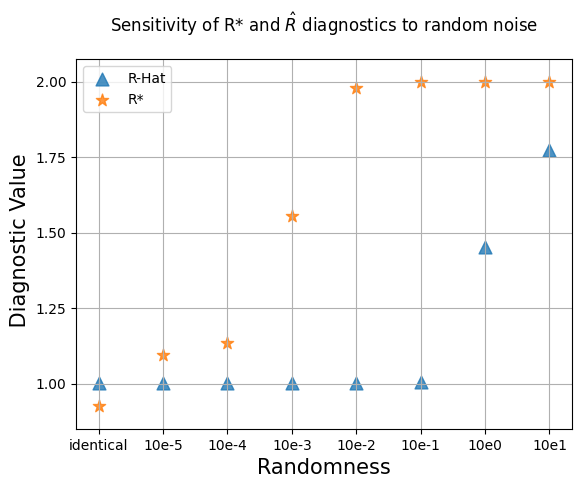

In [6]:
x = [2, 3, 4, 5, 6, 7, 8, 9]
y= [rhat_id['xsec_0'], rhat1['xsec_0'], rhat2['xsec_0'], rhat3['xsec_0'], rhat4['xsec_0'], rhat5['xsec_0'], rhat6['xsec_0'], rhat7['xsec_0'] ] 
lists=[list_id, list1, list2, list3, list4, list5, list6, list7]
ymin, ymax = min(y), max(y)
pad =0.2 #(ymax - ymin) * 0.3
plt.ylim(ymin-0.15, ymax + 0.3)
plt.xticks([2, 3, 4, 5, 6, 7, 8, 9], ['identical','10e-5', '10e-4', '10e-3', '10e-2', '10e-1', '10e0', '10e1'])
plt.yticks([1.00, 1.25, 1.50, 1.75, 2.00], ['1.00','1.25', '1.50', '1.75', '2.00'])

plt.scatter(x, y, alpha=0.8, s=85, marker='^', label= 'R-Hat')
plt.scatter(x, lists, alpha=0.8, s=85, marker='*', label='R*')
plt.legend()

plt.rcParams["font.family"] = "Times"

#plt.gca().yaxis.set_major_locator(plt.MaxNLocator(5))   

plt.title(r'Sensitivity of R* and $\hat{R}$ diagnostics to random noise', pad=20)
plt.xlabel('Randomness', fontsize=15)
plt.ylabel(' Diagnostic Value', fontsize=15)
plt.savefig('filename.png', dpi=900)
plt.grid(True)
plt.show()



# R-Hat run on Asimov Fits

### Asimov A22 Job 11 and Asimov A22 Job 12

In [2]:
path_to_folder= Path("../models/demo_files 2/asimov_fits/asimov_AJ11vsAJ12")


files=[f"{path_to_folder}/{x}" for x in os.listdir(path_to_folder)] 




paths = [files]
for i in paths:
    print(i)
# chain_list [for file in folder ChainHandler(input_file, chain_name, verbose=verbse)]: Handler List : Hlist

temp_identical=[]



for lm in paths:
    for x in lm:
        chain_handler = ChainHandler(x, 'posteriors', verbose='verbose')
            
        # Process all the files
        #chain_handler.ignore_plots(["xsec_20", "xsec_19",'baseline', 'density', 'Ye', 'sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp'])
        chain_handler.ignore_plots(["LogL_systematic_xsec_cov", "LogL"])
        chain_handler.add_additional_plots(["xsec_", 'sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp'])
        # chain_handler.add_additional_plots("LogL", exact=True)
        #We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
        # chain_handler.add_additional_plots(fitting_label, True)

        # Finally we can do some cuts to get rid of things like burn-in
        chain_handler.add_new_cuts(["step>10000"])
        chain_handler.add_new_cuts(["LogL_systematic_xsec_cov<12345"])

        # Last step is  convert the chain data files into a pandas dataframe
        y= chain_handler.convert_ttree_to_array()


        if lm == files:
            temp_identical.append(chain_handler)
 

identical_data = temp_identical[0]
identical_data2= temp_identical[1]





res=[] #converts the DatFrames into numpy arrays, appends them to a list (res)
a= [identical_data, identical_data2]
for n in a:
    new= n.ttree_array.values
    res.append(new)
print(len(res[0]))
print(len(res[1]))

lengths = [n.shape[0] for n in res]
min_len = min(lengths)

res_trimmed = [arr[:min_len, :] for arr in res]
chains_id = np.stack(res_trimmed)

param_names = identical_data2.ttree_array.columns.tolist()
                                                                                           
data_id = az.from_dict(posterior={name: chains_id[:,:,i] for i, name in enumerate(param_names)})
rhat_id= az.rhat(data_id)

print(rhat_id)

['../models/demo_files 2/asimov_fits/asimov_AJ11vsAJ12/trimmed_MaCh3-joint2021_asimovA22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_2.root', '../models/demo_files 2/asimov_fits/asimov_AJ11vsAJ12/trimmed_MaCh3-joint2021_asimovA22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_1.root']
Attempting to open ../models/demo_files 2/asimov_fits/asimov_AJ11vsAJ12/trimmed_MaCh3-joint2021_asimovA22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_2.root
Succesfully opened ../models/demo_files 2/asimov_fits/asimov_AJ11vsAJ12/trimmed_MaCh3-joint2021_asimovA22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_2.root:posteriors
Using 12 threads and requiring 1.003 Gb memory
Using the following branches: 
  -> delm2_12
  -> delm2_23
  -> delta_cp
  -> sin2th_12
  -> sin2th_13
  -> sin2th_23
  -> xsec_0
  -> xsec_1
  -> xsec_10
  -> xsec_100
  -> xsec_101
  -> xsec_102
  -> xsec_103
  -> xsec_104
  -> xsec_105
  -> xsec_106
  -> xsec_107
  -> xsec_108
  -> xsec_109
  -> xsec_11
  -> 

### Asimov A22 Job 11 and Asimov B22 Job 11

In [ ]:
path_to_folder= Path("../models/demo_files 2/asimov_fits/asimov_AJ11vsBJ11")


files=[f"{path_to_folder}/{x}" for x in os.listdir(path_to_folder)] 




paths = [files]
for i in paths:
    print(i)
# chain_list [for file in folder ChainHandler(input_file, chain_name, verbose=verbse)]: Handler List : Hlist

temp_identical=[]



for lm in paths:
    for x in lm:
        chain_handler = ChainHandler(x, 'posteriors', verbose='verbose')
            
        # Process all the files
        #chain_handler.ignore_plots(["xsec_20", "xsec_19",'baseline', 'density', 'Ye', 'sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp'])
        chain_handler.ignore_plots(["LogL_systematic_xsec_cov", "LogL"])
        chain_handler.add_additional_plots(["xsec_", 'sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp'])
        # chain_handler.add_additional_plots("LogL", exact=True)
        #We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
        # chain_handler.add_additional_plots(fitting_label, True)

        # Finally we can do some cuts to get rid of things like burn-in
        chain_handler.add_new_cuts(["step>10000"])
        chain_handler.add_new_cuts(["LogL_systematic_xsec_cov<12345"])

        # Last step is  convert the chain data files into a pandas dataframe
        y= chain_handler.convert_ttree_to_array()


        if lm == files:
            temp_identical.append(chain_handler)
 

identical_data = temp_identical[0]
identical_data2= temp_identical[1]





res=[] #converts the DatFrames into numpy arrays, appends them to a list (res)
a= [identical_data, identical_data2]
for n in a:
    new= n.ttree_array.values
    res.append(new)
print(len(res[0]))
print(len(res[1]))

lengths = [n.shape[0] for n in res]
min_len = min(lengths)

res_trimmed = [arr[:min_len, :] for arr in res]
chains_id = np.stack(res_trimmed)

param_names = identical_data2.ttree_array.columns.tolist()
                                                                                           
data_id = az.from_dict(posterior={name: chains_id[:,:,i] for i, name in enumerate(param_names)})
rhat_id= az.rhat(data_id)

print(rhat_id)


FileNotFoundError: [Errno 2] No such file or directory: '../models/demo_files 2/asimov_fits/asimov_AJ11vsBJ12'